# Data Preprocessing - Water Potability

## Thành viên 2

Phần preprocessing phụ trách:

1. Phân tích outlier.
2. Chuẩn hóa dữ liệu bằng `StandardScaler`.
3. Xây dựng preprocessing pipeline.
4. Kiểm tra và phòng tránh data leakage.
5. Xây dựng `schema.json` và quy tắc kiểm tra feature.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

In [2]:
possible_paths = [
    Path("../data/water_potability.csv"),
    Path("ai-models/data/water_potability.csv"),
    Path("../ai-models/data/water_potability.csv"),
]

data_path = None

for path in possible_paths:
    if path.exists():
        data_path = path
        break

if data_path is None:
    raise FileNotFoundError("Không tìm thấy water_potability.csv")

df = pd.read_csv(data_path)

print("Dataset path:", data_path.resolve())
print("Dataset shape:", df.shape)

Dataset path: F:\4\Hoc may co ban\WaterQualityProject\ai-models\data\water_potability.csv
Dataset shape: (3276, 10)


## 1. Phân tích Outlier

Mục tiêu:

- Phát hiện các giá trị nằm ngoài khoảng thông thường của từng đặc trưng.
- Sử dụng phương pháp IQR để thống kê số lượng outlier.
- Chưa tự động xóa outlier ở bước này vì các giá trị cực trị có thể vẫn là
  những quan sát hợp lệ của chất lượng nước.
- Quyết định xử lý sẽ được đưa ra sau khi xem xét kết quả thực tế.

In [3]:
feature_columns = [
    "ph",
    "Hardness",
    "Solids",
    "Chloramines",
    "Sulfate",
    "Conductivity",
    "Organic_carbon",
    "Trihalomethanes",
    "Turbidity"
]

print("Số feature:", len(feature_columns))

Số feature: 9


In [4]:
outlier_results = []

for feature in feature_columns:
    series = df[feature].dropna()

    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outlier_count = (
        (series < lower_bound) |
        (series > upper_bound)
    ).sum()

    outlier_percent = outlier_count / len(series) * 100

    outlier_results.append({
        "Feature": feature,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "Lower_Bound": lower_bound,
        "Upper_Bound": upper_bound,
        "Outlier_Count": outlier_count,
        "Outlier_Percent": outlier_percent
    })

outlier_summary = pd.DataFrame(outlier_results)

outlier_summary = outlier_summary.round({
    "Q1": 2,
    "Q3": 2,
    "IQR": 2,
    "Lower_Bound": 2,
    "Upper_Bound": 2,
    "Outlier_Percent": 2
})

outlier_summary

,Feature,Q1,Q3,IQR,Lower_Bound,Upper_Bound,Outlier_Count,Outlier_Percent
0,ph,6.09,8.06,1.97,3.14,11.02,46,1.65
1,Hardness,176.85,216.67,39.82,117.13,276.39,83,2.53
2,Solids,15666.69,27332.76,11666.07,-1832.42,44831.87,47,1.43
3,Chloramines,6.13,8.11,1.99,3.15,11.10,61,1.86
4,Sulfate,307.70,359.95,52.25,229.32,438.33,41,1.64
5,Conductivity,365.73,481.79,116.06,191.65,655.88,11,0.34
6,Organic_carbon,12.07,16.56,4.49,5.33,23.30,25,0.76
7,Trihalomethanes,55.84,77.34,21.49,23.61,109.58,33,1.06
8,Turbidity,3.44,4.50,1.06,1.85,6.09,19,0.58


In [5]:
outlier_summary_sorted = (
    outlier_summary
    .sort_values("Outlier_Count", ascending=False)
    .reset_index(drop=True)
)

outlier_summary_sorted

,Feature,Q1,Q3,IQR,Lower_Bound,Upper_Bound,Outlier_Count,Outlier_Percent
0,Hardness,176.85,216.67,39.82,117.13,276.39,83,2.53
1,Chloramines,6.13,8.11,1.99,3.15,11.10,61,1.86
2,Solids,15666.69,27332.76,11666.07,-1832.42,44831.87,47,1.43
3,ph,6.09,8.06,1.97,3.14,11.02,46,1.65
4,Sulfate,307.70,359.95,52.25,229.32,438.33,41,1.64
5,Trihalomethanes,55.84,77.34,21.49,23.61,109.58,33,1.06
6,Organic_carbon,12.07,16.56,4.49,5.33,23.30,25,0.76
7,Turbidity,3.44,4.50,1.06,1.85,6.09,19,0.58
8,Conductivity,365.73,481.79,116.06,191.65,655.88,11,0.34


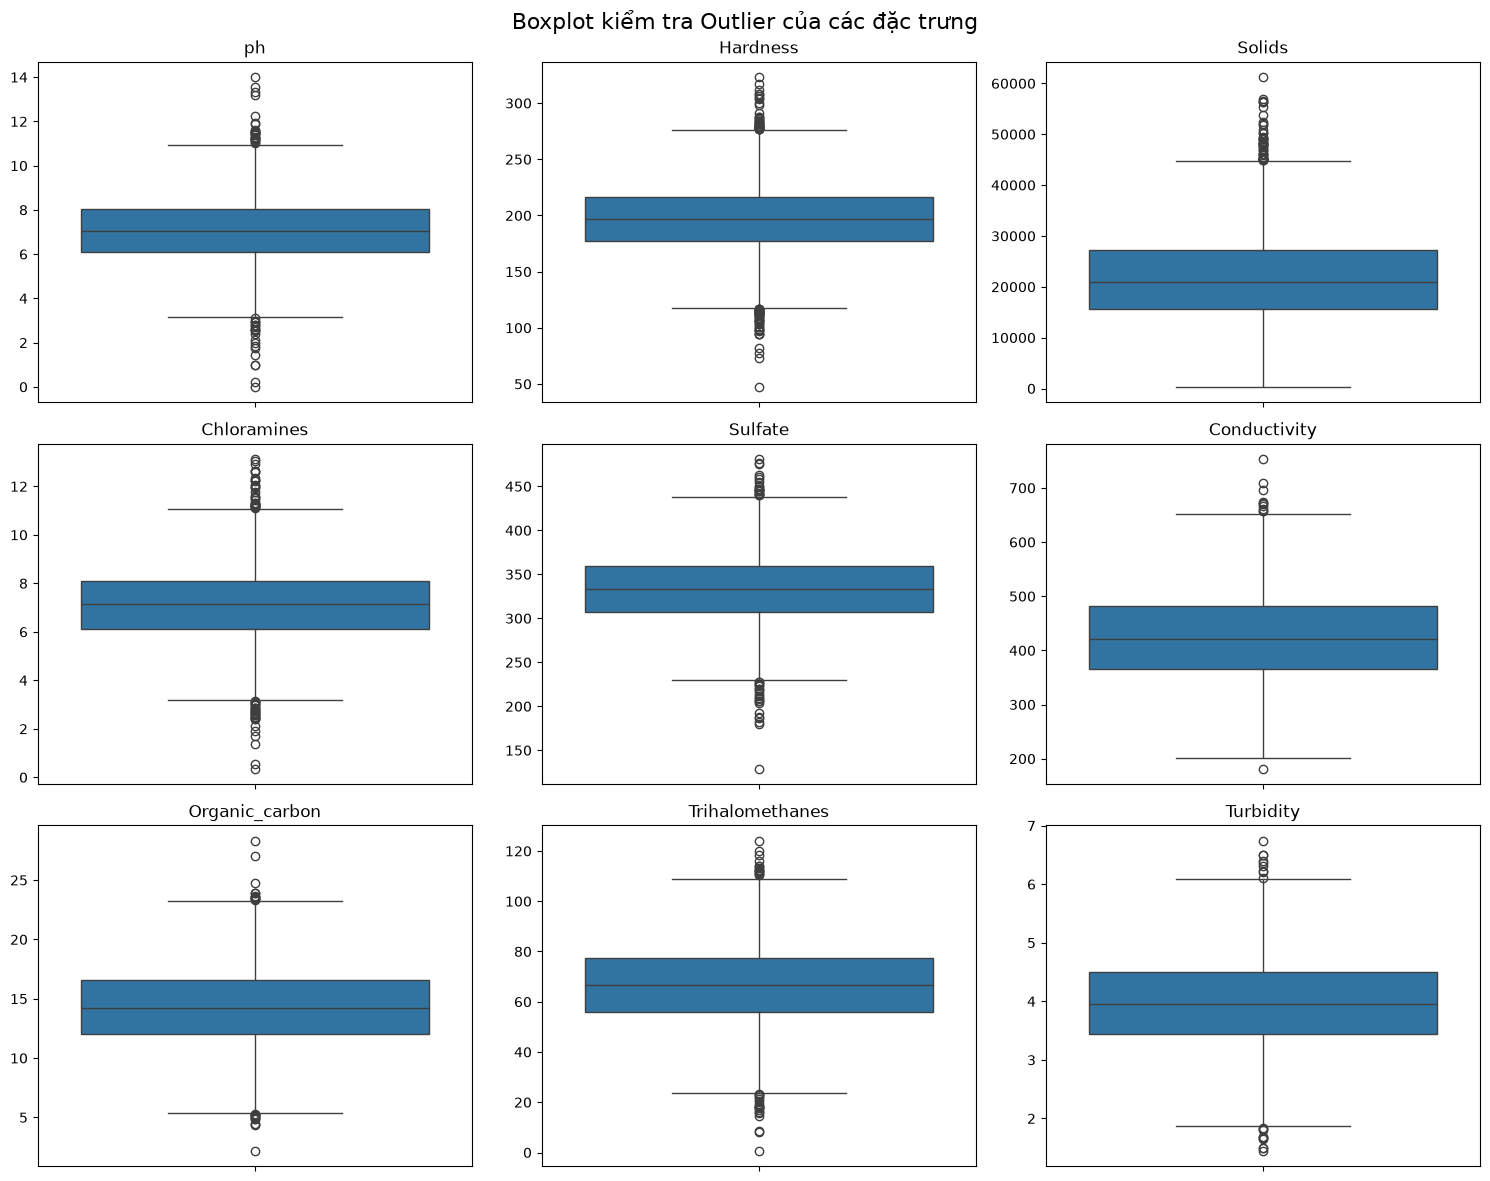

In [6]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))

axes = axes.flatten()

for ax, feature in zip(axes, feature_columns):
    sns.boxplot(
        y=df[feature],
        ax=ax
    )

    ax.set_title(feature)
    ax.set_ylabel("")

plt.suptitle(
    "Boxplot kiểm tra Outlier của các đặc trưng",
    fontsize=16
)

plt.tight_layout()
plt.show()

### Nhận xét Outlier

Phương pháp IQR được sử dụng để phát hiện các giá trị nằm ngoài khoảng:

`[Q1 - 1.5 × IQR, Q3 + 1.5 × IQR]`

Kết quả cho thấy tất cả các đặc trưng đều có một số outlier, tuy nhiên
tỷ lệ nhìn chung khá thấp:

- `Hardness`: 83 outlier, khoảng 2.53%.
- `Chloramines`: 61 outlier, khoảng 1.86%.
- `ph`: 46 outlier, khoảng 1.65%.
- `Sulfate`: 41 outlier, khoảng 1.64%.
- `Solids`: 47 outlier, khoảng 1.43%.
- `Trihalomethanes`: 33 outlier, khoảng 1.06%.
- `Organic_carbon`: 25 outlier, khoảng 0.76%.
- `Turbidity`: 19 outlier, khoảng 0.58%.
- `Conductivity`: 11 outlier, khoảng 0.34%.

Không có đặc trưng nào có tỷ lệ outlier vượt quá 3%.

Các giá trị được IQR đánh dấu là outlier chỉ là những quan sát bất thường
theo tiêu chí thống kê, chưa thể kết luận đây là dữ liệu sai.

Trong bài toán chất lượng nước, các giá trị cực trị vẫn có thể là những
mẫu nước thực tế và mang thông tin hữu ích cho mô hình.

### Quyết định xử lý

Ở phiên bản preprocessing hiện tại, không xóa các outlier khỏi dataset.

Lý do:

1. Tỷ lệ outlier tương đối thấp.
2. Không có bằng chứng cho thấy các giá trị này là dữ liệu nhập sai.
3. Việc loại bỏ tự động có thể làm mất thông tin quan trọng.
4. Ảnh hưởng của outlier sẽ được tiếp tục đánh giá thông qua kết quả
   huấn luyện và so sánh các mô hình.

Các đặc trưng sẽ được chuẩn hóa trong preprocessing pipeline.
Việc chuẩn hóa phải được fit trên tập train thay vì toàn bộ dataset
để tránh data leakage.

## 2. Xác định Feature và Target

Dataset sử dụng:

- 9 đặc trưng đầu vào (`X`)
- 1 biến mục tiêu (`y`): `Potability`

Ở bước này chỉ tách feature và target.

Chưa thực hiện:
- Điền missing values.
- StandardScaler.
- Train/Test Split.
- Resampling hoặc cân bằng dữ liệu.

Mục đích là kiểm tra cấu trúc dữ liệu trước khi xây dựng preprocessing pipeline.

In [7]:
TARGET_COLUMN = "Potability"

TARGET_COLUMN

'Potability'

In [8]:
feature_columns = [
    "ph",
    "Hardness",
    "Solids",
    "Chloramines",
    "Sulfate",
    "Conductivity",
    "Organic_carbon",
    "Trihalomethanes",
    "Turbidity"
]

print("Số lượng feature:", len(feature_columns))
print("Feature:", feature_columns)

Số lượng feature: 9
Feature: ['ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate', 'Conductivity', 'Organic_carbon', 'Trihalomethanes', 'Turbidity']


In [9]:
required_columns = feature_columns + [TARGET_COLUMN]

missing_columns = [
    column
    for column in required_columns
    if column not in df.columns
]

if missing_columns:
    raise ValueError(
        f"Dataset thiếu các cột bắt buộc: {missing_columns}"
    )

print("Tất cả feature và target đều tồn tại trong dataset.")

Tất cả feature và target đều tồn tại trong dataset.


In [10]:
X = df[feature_columns].copy()
y = df[TARGET_COLUMN].copy()

print("Shape X:", X.shape)
print("Shape y:", y.shape)

Shape X: (3276, 9)
Shape y: (3276,)


In [11]:
print("Các cột trong X:")
print(X.columns.tolist())

print("\nTarget có nằm trong X không?")
print(TARGET_COLUMN in X.columns)

Các cột trong X:
['ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate', 'Conductivity', 'Organic_carbon', 'Trihalomethanes', 'Turbidity']

Target có nằm trong X không?
False


In [12]:
target_values = sorted(y.dropna().unique())

print("Các giá trị của target:", target_values)

Các giá trị của target: [np.int64(0), np.int64(1)]


In [13]:
feature_dtypes = X.dtypes

feature_dtypes

ph                 float64
Hardness           float64
Solids             float64
Chloramines        float64
Sulfate            float64
Conductivity       float64
Organic_carbon     float64
Trihalomethanes    float64
Turbidity          float64
dtype: object

In [14]:
non_numeric_features = X.select_dtypes(
    exclude=np.number
).columns.tolist()

print("Feature không phải numeric:", non_numeric_features)

Feature không phải numeric: []


In [15]:
X_missing = pd.DataFrame({
    "Missing": X.isnull().sum(),
    "Percent": (
        X.isnull().mean() * 100
    ).round(2)
})

X_missing

,Missing,Percent
ph,491,14.99
Hardness,0,0.00
Solids,0,0.00
Chloramines,0,0.00
Sulfate,781,23.84
Conductivity,0,0.00
Organic_carbon,0,0.00
Trihalomethanes,162,4.95
Turbidity,0,0.00


In [16]:
print("Missing trong target:", y.isnull().sum())

Missing trong target: 0


### Nhận xét Feature và Target

Dataset sau khi tách gồm:

- `X`: 3276 mẫu và 9 đặc trưng đầu vào.
- `y`: 3276 nhãn `Potability`.

Biến mục tiêu không nằm trong tập `X`, do đó chưa xuất hiện target leakage.

Tất cả 9 đặc trưng đầu vào đều là dữ liệu số, vì vậy bài toán hiện tại
không cần xử lý biến phân loại bằng One-Hot Encoding.

Target chỉ gồm hai giá trị:

- `0`: Not Potable.
- `1`: Potable.

Missing values chỉ xuất hiện ở các feature, trong khi target không có missing value.

Ở bước tiếp theo, missing values sẽ không được điền trực tiếp trên toàn bộ dataset.
Việc imputation phải được đặt trong preprocessing pipeline và fit trên dữ liệu train
để tránh data leakage.

## 3. Xử lý Missing Values

Dataset có missing values ở ba đặc trưng:

- `ph`
- `Sulfate`
- `Trihalomethanes`

Chiến lược được lựa chọn là sử dụng `SimpleImputer(strategy="median")`.

Lý do:

1. Tất cả các feature đều là dữ liệu số.
2. Dataset có một số outlier, vì vậy median ít bị ảnh hưởng bởi giá trị cực trị hơn mean.
3. Imputation sẽ được đặt trong preprocessing pipeline.
4. Imputer chỉ được `fit` trên tập train sau khi thực hiện Train/Test Split để tránh data leakage.

Ở bước này chỉ xây dựng cấu hình imputer, chưa fit trên toàn bộ dataset.

In [17]:
missing_features = (
    X.isnull()
    .sum()
    .loc[lambda s: s > 0]
)

missing_features

ph                 491
Sulfate            781
Trihalomethanes    162
dtype: int64

In [18]:
missing_percent = (
    X.isnull()
    .mean()
    .mul(100)
    .round(2)
)

missing_summary = pd.DataFrame({
    "Missing_Count": X.isnull().sum(),
    "Missing_Percent": missing_percent
})

missing_summary = missing_summary[
    missing_summary["Missing_Count"] > 0
]

missing_summary

,Missing_Count,Missing_Percent
ph,491,14.99
Sulfate,781,23.84
Trihalomethanes,162,4.95


In [19]:
median_imputer = SimpleImputer(
    strategy="median"
)

median_imputer

,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a feature has nomissing values at fit/train time, the feature won't appear onthe missing indicator even if there are missing values attransform/test time.",False
,"keep_empty_features keep_empty_features: bool, default=FalseIf True, features that consist exclusively of missing values when`fit` is called are returned in results when `transform` is called.The imputed value is always `0` except when `strategy=""constant""`in which case `fill_value` will be used instead... versionadded:: 1.2",False


In [20]:
missing_value_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    )
])

missing_value_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness des

In [21]:
from sklearn.utils.validation import check_is_fitted
from sklearn.exceptions import NotFittedError

try:
    check_is_fitted(missing_value_pipeline)
    print("Pipeline đã được fit.")
except NotFittedError:
    print("Pipeline chưa được fit - đúng yêu cầu hiện tại.")

Pipeline chưa được fit - đúng yêu cầu hiện tại.


### Nhận xét và quyết định xử lý Missing Values

Missing values xuất hiện ở:

- `ph`: 491 giá trị thiếu, khoảng 14.99%.
- `Sulfate`: 781 giá trị thiếu, khoảng 23.84%.
- `Trihalomethanes`: 162 giá trị thiếu, khoảng 4.95%.

Không thực hiện `dropna()` vì việc xóa toàn bộ các dòng có missing values
có thể làm mất một lượng dữ liệu đáng kể, đặc biệt với `Sulfate`.

Phương án được lựa chọn là:

`SimpleImputer(strategy="median")`

Median được chọn thay cho mean vì dữ liệu có một số giá trị ngoại lệ
và median ít nhạy cảm hơn với outlier.

Imputer sẽ được đặt trong pipeline và chỉ được fit trên dữ liệu train
sau khi Train/Test Split hoàn tất.

Tập test chỉ sử dụng phép biến đổi đã học từ train và không được dùng
để tính median.

Quy trình đúng:

Train/Test Split  
→ Fit Imputer trên Train  
→ Transform Train  
→ Transform Test bằng Imputer đã fit

Cách làm này giúp hạn chế data leakage.

## 4. Chuẩn hóa dữ liệu bằng StandardScaler

Các đặc trưng trong dataset có thang đo rất khác nhau.

Ví dụ:

- `ph` thường có giá trị ở khoảng vài đơn vị.
- `Hardness` có giá trị hàng trăm.
- `Solids` có thể có giá trị hàng chục nghìn.
- `Conductivity` có giá trị hàng trăm.

Sự khác biệt về thang đo có thể ảnh hưởng đến các mô hình nhạy với khoảng cách
hoặc độ lớn của feature.

Trong project này, `StandardScaler` được sử dụng cho:

- Logistic Regression.
- SVM.

KNN của Thành viên 1 cũng là mô hình nhạy với khoảng cách và sẽ cần scaling.

Random Forest không bắt buộc phải chuẩn hóa dữ liệu vì mô hình dựa trên cây quyết định.

Quan trọng: `StandardScaler` chỉ được fit trên dữ liệu train sau khi Train/Test Split,
không được fit trên toàn bộ dataset để tránh data leakage.

In [22]:
feature_scale_summary = pd.DataFrame({
    "Min": X.min(),
    "Max": X.max(),
    "Mean": X.mean(),
    "Std": X.std()
}).round(2)

feature_scale_summary

,Min,Max,Mean,Std
ph,0.00,14.00,7.08,1.59
Hardness,47.43,323.12,196.37,32.88
Solids,320.94,61227.20,22014.09,8768.57
Chloramines,0.35,13.13,7.12,1.58
Sulfate,129.00,481.03,333.78,41.42
Conductivity,181.48,753.34,426.21,80.82
Organic_carbon,2.20,28.30,14.28,3.31
Trihalomethanes,0.74,124.00,66.40,16.18
Turbidity,1.45,6.74,3.97,0.78


In [23]:
standard_scaler = StandardScaler()

standard_scaler

,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [24]:
scaled_preprocessing_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    )
])

scaled_preprocessing_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('scaler', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account fo

In [25]:
try:
    check_is_fitted(scaled_preprocessing_pipeline)
    print("Pipeline đã được fit.")
except NotFittedError:
    print("Scaled pipeline chưa được fit - đúng yêu cầu hiện tại.")

Scaled pipeline chưa được fit - đúng yêu cầu hiện tại.


### Quyết định chuẩn hóa dữ liệu

Preprocessing pipeline dành cho các mô hình cần scaling gồm:

`SimpleImputer(strategy="median")`
→ `StandardScaler()`

Trong đó:

1. `SimpleImputer` xử lý missing values bằng median.
2. `StandardScaler` chuẩn hóa các đặc trưng về cùng thang đo.

Pipeline này sẽ được sử dụng cho Logistic Regression và SVM của Thành viên 2.

Pipeline chưa được fit ở giai đoạn này.

Sau khi hai thành viên thống nhất Train/Test Split, quy trình chính thức sẽ là:

Train/Test Split  
→ Fit Pipeline trên `X_train`  
→ Transform `X_train`  
→ Transform `X_test` bằng pipeline đã fit

Không thực hiện:

`fit(X_test)`

hoặc:

`fit_transform(X_test)`

vì như vậy sẽ gây data leakage.

Random Forest không bắt buộc phải sử dụng StandardScaler do đặc tính của mô hình cây.

## 5. Feature Schema

Schema đầu vào của mô hình được lưu tại:

`ai-models/models/schema.json`

Schema xác định:

- Tên và kiểu của 9 feature đầu vào.
- Thứ tự feature sử dụng khi train và predict.
- Biến mục tiêu `Potability`.
- Ánh xạ nhãn 0/1.
- Chiến lược preprocessing chính.

Việc cố định `feature_order` giúp đảm bảo dữ liệu truyền từ Frontend
→ Backend → AI Service có cùng cấu trúc với dữ liệu được sử dụng để
huấn luyện model.

Target `Potability` không phải là dữ liệu đầu vào khi thực hiện dự đoán.